# Practica M27
El objetivo de esta actividad es que realices un análisis de agrupación por K-Medias a una base de datos de manera que puedas generar conclusiones de acuerdo a diversas categorías.
***



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('iris.csv')
df

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Virginica
146,6.3,2.5,5.0,1.9,Virginica
147,6.5,3.0,5.2,2.0,Virginica
148,6.2,3.4,5.4,2.3,Virginica


* ### Agrupa las observaciones de la tabla descargada mediante el algoritmo de K-Medias sin realizar ningún tipo de transformación de los datos originales. Para dicho efecto, determina el número óptimo de clusters tanto por el criterio del gráfico de codo así como por el indicador Silhouette.

In [3]:
raw_data = df.iloc[:,[0,1]].values
raw_data

array([[5.1, 3.5],
       [4.9, 3. ],
       [4.7, 3.2],
       [4.6, 3.1],
       [5. , 3.6],
       [5.4, 3.9],
       [4.6, 3.4],
       [5. , 3.4],
       [4.4, 2.9],
       [4.9, 3.1],
       [5.4, 3.7],
       [4.8, 3.4],
       [4.8, 3. ],
       [4.3, 3. ],
       [5.8, 4. ],
       [5.7, 4.4],
       [5.4, 3.9],
       [5.1, 3.5],
       [5.7, 3.8],
       [5.1, 3.8],
       [5.4, 3.4],
       [5.1, 3.7],
       [4.6, 3.6],
       [5.1, 3.3],
       [4.8, 3.4],
       [5. , 3. ],
       [5. , 3.4],
       [5.2, 3.5],
       [5.2, 3.4],
       [4.7, 3.2],
       [4.8, 3.1],
       [5.4, 3.4],
       [5.2, 4.1],
       [5.5, 4.2],
       [4.9, 3.1],
       [5. , 3.2],
       [5.5, 3.5],
       [4.9, 3.6],
       [4.4, 3. ],
       [5.1, 3.4],
       [5. , 3.5],
       [4.5, 2.3],
       [4.4, 3.2],
       [5. , 3.5],
       [5.1, 3.8],
       [4.8, 3. ],
       [5.1, 3.8],
       [4.6, 3.2],
       [5.3, 3.7],
       [5. , 3.3],
       [7. , 3.2],
       [6.4, 3.2],
       [6.9,

In [4]:
wcss = []
for index in range (1,11):
    kmeans = KMeans(n_clusters= index, init = 'k-means++', random_state = 2)
    kmeans.fit (raw_data)

    wcss.append(kmeans.inertia_)

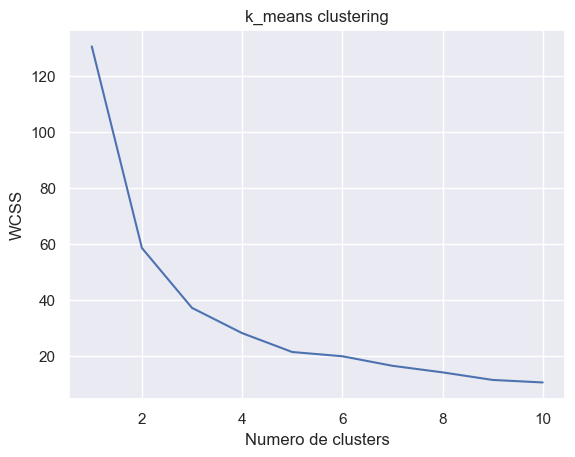

In [5]:
# Graficacion del "Codo de Jambu"
sns.set()
plt.plot(range(1,11),wcss)
plt.title('k_means clustering')
plt.xlabel('Numero de clusters')
plt.ylabel('WCSS') # Weighted cluster sum of squares
plt.show()

In [6]:
kmeans = KMeans(n_clusters= 3, init= 'k-means++', random_state = 42)
cluster_values= kmeans.fit_predict(raw_data)
print(cluster_values)

[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 0 0 0 1 0 1 0 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1
 0 0 0 0 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 0 0 0 1 0 0 0 0
 0 0 1 1 0 0 0 0 1 0 1 0 1 0 0 1 1 0 0 0 0 0 1 1 0 0 0 1 0 0 0 1 0 0 0 1 0
 0 1]


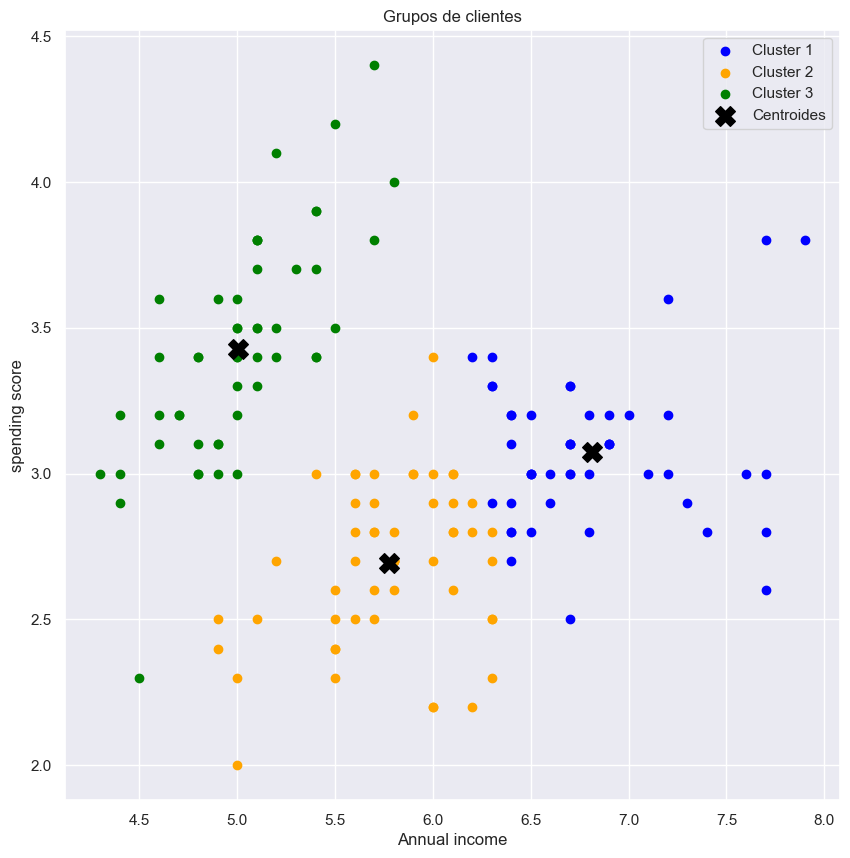

In [7]:
plt.figure(figsize= (10,10))
plt.scatter(raw_data[cluster_values == 0,0], raw_data[cluster_values == 0,1], c = 'blue', label = 'Cluster 1')
plt.scatter(raw_data[cluster_values == 1,0], raw_data[cluster_values == 1,1], c = 'orange', label = 'Cluster 2')
plt.scatter(raw_data[cluster_values == 2,0], raw_data[cluster_values == 2,1], c = 'green', label = 'Cluster 3')



plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1], c = 'black',label = 'Centroides',marker='X',s=200,)

plt.title('Grupos de clientes')
plt.xlabel('Annual income')
plt.ylabel('spending score')
plt.legend()

In [8]:
# Criterio de silueta ('silhouette')
from sklearn import datasets
from sklearn.metrics import silhouette_score


In [9]:
X = df.iloc[:,[0,1]].to_numpy()
for j  in range(2,12):
    kmeans = KMeans(n_clusters=j, random_state = 42)
    kmeans.fit_predict(X)
    #Calculamos el score de silueta
    score = silhouette_score(X, kmeans.labels_,metric='euclidean')
    print('score silhuoette:', "k= ",j, ':', score)

score silhuoette: k=  2 : 0.4634693772673248
score silhuoette: k=  3 : 0.4450525692083638
score silhuoette: k=  4 : 0.4028471317296809
score silhuoette: k=  5 : 0.34312790770010887
score silhuoette: k=  6 : 0.3901380642183856
score silhuoette: k=  7 : 0.4013232244605618
score silhuoette: k=  8 : 0.38847422344012994
score silhuoette: k=  9 : 0.37265574788548234
score silhuoette: k=  10 : 0.4023683501385767
score silhuoette: k=  11 : 0.41974951752865536


### score silhuoette: k=  3

Al analizar el dataframe, se observa que contiene tres variedades de plantas. Esto sugiere que el número ideal de grupos para la segmentación es tres. Aunque una de las variedades resulta ser significativamente diferente de las otras dos, lo cual podría llevar a pensar que lo más evidente sería establecer K igual a 2, tiene más sentido optar por tres grupos. Esta elección se justifica porque refleja fielmente la estructura original del conjunto de datos y permite una clasificación más representativa de las variedades presentes.

* ### Repite el ejercicio anterior después de haber transformado tus datos originales a dos columnas, mediante reducción por PCA. Gráfica los grupos obtenidos considerando las dos dimensiones resultantes.

In [10]:
pca_data = df.iloc[:,[0,1,2,3]].values
pca_data

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [11]:
from sklearn import decomposition
pca = decomposition.PCA(n_components=2)
pca.fit(pca_data)
pca_data = pca.transform(pca_data)
pca_data

array([[-2.68412563,  0.31939725],
       [-2.71414169, -0.17700123],
       [-2.88899057, -0.14494943],
       [-2.74534286, -0.31829898],
       [-2.72871654,  0.32675451],
       [-2.28085963,  0.74133045],
       [-2.82053775, -0.08946138],
       [-2.62614497,  0.16338496],
       [-2.88638273, -0.57831175],
       [-2.6727558 , -0.11377425],
       [-2.50694709,  0.6450689 ],
       [-2.61275523,  0.01472994],
       [-2.78610927, -0.235112  ],
       [-3.22380374, -0.51139459],
       [-2.64475039,  1.17876464],
       [-2.38603903,  1.33806233],
       [-2.62352788,  0.81067951],
       [-2.64829671,  0.31184914],
       [-2.19982032,  0.87283904],
       [-2.5879864 ,  0.51356031],
       [-2.31025622,  0.39134594],
       [-2.54370523,  0.43299606],
       [-3.21593942,  0.13346807],
       [-2.30273318,  0.09870885],
       [-2.35575405, -0.03728186],
       [-2.50666891, -0.14601688],
       [-2.46882007,  0.13095149],
       [-2.56231991,  0.36771886],
       [-2.63953472,

In [12]:
wcss2 = []
for index in range (1,11):
    kmeans = KMeans(n_clusters= index, init = 'k-means++', random_state = 2)
    kmeans.fit (pca_data)

    wcss2.append(kmeans.inertia_)

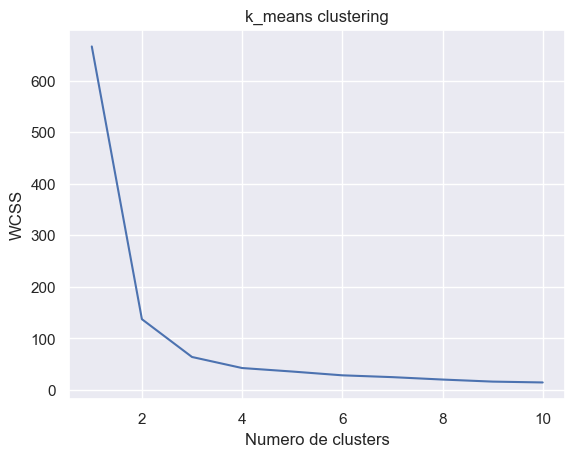

In [13]:
sns.set()
plt.plot(range(1,11),wcss2)
plt.title('k_means clustering')
plt.xlabel('Numero de clusters')
plt.ylabel('WCSS') # Weighted cluster sum of squares
plt.show()

In [14]:
kmeans = KMeans(n_clusters= 3, init= 'k-means++', random_state = 42)
cluster_values= kmeans.fit_predict(pca_data)
print(cluster_values)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 0 0 0 0 2 0 0 0 0
 0 0 2 2 0 0 0 0 2 0 2 0 2 0 0 2 2 0 0 0 0 0 2 0 0 0 0 2 0 0 0 2 0 0 0 2 0
 0 2]


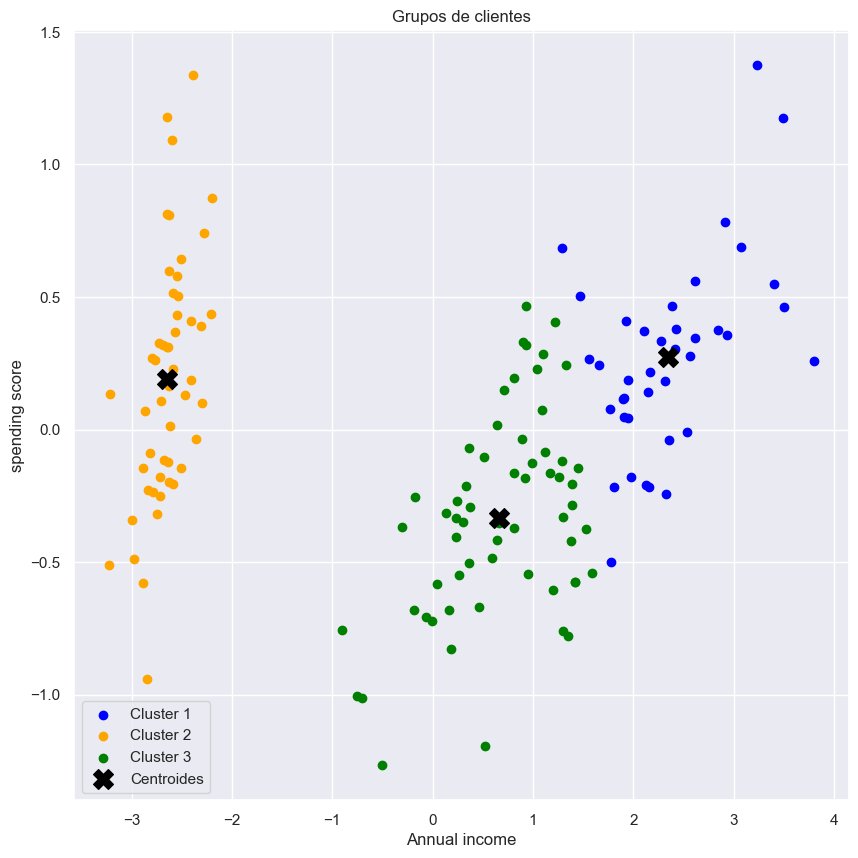

In [15]:
plt.figure(figsize= (10,10))
plt.scatter(pca_data[cluster_values == 0,0], pca_data[cluster_values == 0,1], c = 'blue', label = 'Cluster 1')
plt.scatter(pca_data[cluster_values == 1,0], pca_data[cluster_values == 1,1], c = 'orange', label = 'Cluster 2')
plt.scatter(pca_data[cluster_values == 2,0], pca_data[cluster_values == 2,1], c = 'green', label = 'Cluster 3')

plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1], c = 'black',label = 'Centroides',marker='X',s=200,)

plt.title('Grupos de clientes')
plt.xlabel('Annual income')
plt.ylabel('spending score')
plt.legend()

* ### Compara los resultados de los incisos 2) y 3). ¿Obtuviste los mismos resultados de agrupamiento? Comenta sobre la ventaja práctica de haber efectuado la transformación por PCA antes de aplicar el algoritmo K-Medias.

Al comparar ambos gráficos, se observa que los resultados muestran similitudes importantes. En cada uno, se distinguen claramente dos grupos bien definidos. Además, se identifica un tercer grupo que presenta cierta mezcla o confusión con el segundo, lo que sugiere una superposición parcial entre estos conjuntos de datos.

Posteriormente, al agregar el resto del dataframe y aplicar el método de descomposición PCA, los grupos lograron una mayor definición. Esta técnica permitió afinar la separación entre los conjuntos, haciendo que la clasificación de los datos sea más precisa y clara.